# Exploratory Data Analysis

**Theme:** Why do earthquakes kill so differently across countries?

**Six Datasets used:**
1. **NOAA Significant Earthquake Database** (1960–2026) — seismic events with magnitude, depth, deaths, injuries, damage
2. **GDP per capita** (World Bank) — current US$ per country-year
3. **Population density** (World Bank) — people per sq. km per country-year
4. **Urban population %** (World Bank) — % of total population living in urban areas per country-year
5. **Hospital beds per 1,000** (World Bank) — healthcare infrastructure per country-year
6. **Human Development Index** (UNDP) — composite index of life expectancy, education, and income

---

## 1. Setup & Data Loading

In [ ]:
# libraries
import os
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10, 'axes.titlesize': 13})

BASE = os.path.join('..', 'data')  
print(f'Working directory: {BASE}')

Working directory: ../data


### 1.1 Load Earthquake Data (NOAA)

In [32]:
eq_raw = pd.read_csv(
    os.path.join(BASE, 'earthquakes-2026-03-14_15-39-57_+0100.tsv'),
    sep='\t', header=0, skiprows=[1]
)

print(f'Raw earthquake dataset: {eq_raw.shape[0]} rows × {eq_raw.shape[1]} columns')
eq_raw.head()

Raw earthquake dataset: 2709 rows × 39 columns


,Search Parameters,Year,Mo,Dy,Hr,Mn,Sec,Tsu,Vol,Location Name,...,Total Missing,Total Missing Description,Total Injuries,Total Injuries Description,Total Damage ($Mil),Total Damage Description,Total Houses Destroyed,Total Houses Destroyed Description,Total Houses Damaged,Total Houses Damaged Description
0,NaN,1960,1,13,15.0,40.0,34.0,1896.0,NaN,"PERU: AREQUIPA,CHUQUIBAMBA,CARAVELI,COTAHUASI",...,NaN,NaN,200.0,3.0,NaN,3.0,NaN,3.0,NaN,NaN
1,NaN,1960,1,15,9.0,30.0,21.6,NaN,NaN,"PERU: LIMA,NAZCA,ICA,HUANCAVELIC,PALPA,HUAITARA",...,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN
2,NaN,1960,2,2,23.0,51.0,59.0,NaN,NaN,CHINA: GANSU PROVINCE,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN
3,NaN,1960,2,21,8.0,13.0,31.0,NaN,NaN,ALGERIA: MELOUZA,...,NaN,NaN,88.0,2.0,NaN,2.0,NaN,NaN,NaN,NaN
4,NaN,1960,2,29,23.0,40.0,14.0,1897.0,NaN,MOROCCO: AGADIR,...,NaN,NaN,25000.0,4.0,120.0,4.0,NaN,3.0,NaN,NaN


In [33]:
print('--- Column names and dtypes ---')
eq_raw.info()

--- Column names and dtypes ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2709 entries, 0 to 2708
Data columns (total 39 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Search Parameters                   0 non-null      float64
 1   Year                                2709 non-null   int64  
 2   Mo                                  2709 non-null   int64  
 3   Dy                                  2709 non-null   int64  
 4   Hr                                  2692 non-null   float64
 5   Mn                                  2688 non-null   float64
 6   Sec                                 2677 non-null   float64
 7   Tsu                                 703 non-null    float64
 8   Vol                                 26 non-null     float64
 9   Location Name                       2709 non-null   object 
 10  Latitude                            2709 non-null   float64
 11  Longitude  

### 1.2 Helper: Load World Bank data from ZIP

In [34]:
def load_wb_zip(zip_path, value_name):
    """Load a World Bank indicator from ZIP, melt to long format."""
    with zipfile.ZipFile(zip_path) as z:
        csv_name = [n for n in z.namelist() if n.startswith('API_')][0]
        with z.open(csv_name) as f:
            df = pd.read_csv(f, skiprows=4)
    year_cols = [c for c in df.columns if c.isdigit()]
    melted = df.melt(
        id_vars=['Country Name', 'Country Code'],
        value_vars=year_cols,
        var_name='year_str', value_name=value_name
    )
    melted['year_int'] = pd.to_numeric(melted['year_str'], errors='coerce').astype('Int64')
    melted = melted.drop(columns='year_str')
    melted = melted.rename(columns={'Country Name': 'country_wb'})
    return melted

### 1.3 Dataset 2: GDP per capita (World Bank)

In [35]:
gdp = load_wb_zip(os.path.join(BASE, 'API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.zip'), 'gdp_pc')
print(f'GDP per capita: {gdp.shape[0]} rows × {gdp.shape[1]} columns')
print(f'Countries: {gdp["country_wb"].nunique()}, Year range: {gdp["year_int"].min()} – {gdp["year_int"].max()}')
print(f'Non-null values: {gdp["gdp_pc"].notna().sum()} ({gdp["gdp_pc"].notna().mean()*100:.1f}%)\n')
print(gdp['gdp_pc'].describe().round(2))
print()
gdp.head()

GDP per capita: 17556 rows × 4 columns
Countries: 266, Year range: 1960 – 2025
Non-null values: 14561 (82.9%)

count     14561.00
mean       8701.89
std       17595.34
min          11.80
25%         583.78
50%        1938.81
75%        8045.95
max      288001.43
Name: gdp_pc, dtype: float64



,country_wb,Country Code,gdp_pc,year_int
0,Aruba,ABW,NaN,1960
1,Africa Eastern and Southern,AFE,186.089204,1960
2,Afghanistan,AFG,NaN,1960
3,Africa Western and Central,AFW,121.936832,1960
4,Angola,AGO,NaN,1960


### 1.4 Dataset 3: Population density (World Bank)

In [36]:
pop_dens = load_wb_zip(os.path.join(BASE, 'API_EN.POP.DNST_DS2_en_csv_v2_460.zip'), 'pop_density')
print(f'Population density: {pop_dens.shape[0]} rows × {pop_dens.shape[1]} columns')
print(f'Countries: {pop_dens["country_wb"].nunique()}, Year range: {pop_dens["year_int"].min()} – {pop_dens["year_int"].max()}')
print(f'Non-null values: {pop_dens["pop_density"].notna().sum()} ({pop_dens["pop_density"].notna().mean()*100:.1f}%)\n')
print(pop_dens['pop_density'].describe().round(2))
print()
pop_dens.head()

Population density: 17556 rows × 4 columns
Countries: 266, Year range: 1960 – 2025
Non-null values: 15296 (87.1%)

count    15296.00
mean       300.17
std       1521.98
min          0.10
25%         21.69
50%         57.06
75%        139.08
max      21530.00
Name: pop_density, dtype: float64



,country_wb,Country Code,pop_density,year_int
0,Aruba,ABW,NaN,1960
1,Africa Eastern and Southern,AFE,NaN,1960
2,Afghanistan,AFG,NaN,1960
3,Africa Western and Central,AFW,NaN,1960
4,Angola,AGO,NaN,1960


### 1.5 Dataset 4: Urban population % (World Bank)

In [37]:
urban = load_wb_zip(os.path.join(BASE, 'API_SP.URB.TOTL.IN.ZS_DS2_en_csv_v2_249.zip'), 'urban_pct')
print(f'Urban population %: {urban.shape[0]} rows × {urban.shape[1]} columns')
print(f'Countries: {urban["country_wb"].nunique()}, Year range: {urban["year_int"].min()} – {urban["year_int"].max()}')
print(f'Non-null values: {urban["urban_pct"].notna().sum()} ({urban["urban_pct"].notna().mean()*100:.1f}%)\n')
print(urban['urban_pct'].describe().round(2))
print()
urban.head()

Urban population %: 17556 rows × 4 columns
Countries: 266, Year range: 1960 – 2025
Non-null values: 17225 (98.1%)

count    17225.00
mean        50.57
std         24.79
min          1.84
25%         30.48
50%         49.30
75%         69.53
max        100.00
Name: urban_pct, dtype: float64



,country_wb,Country Code,urban_pct,year_int
0,Aruba,ABW,59.023670,1960
1,Africa Eastern and Southern,AFE,14.640371,1960
2,Afghanistan,AFG,8.122551,1960
3,Africa Western and Central,AFW,13.946480,1960
4,Angola,AGO,10.387104,1960


### 1.6 Dataset 5: Hospital beds per 1,000 (World Bank)

In [38]:
beds = load_wb_zip(os.path.join(BASE, 'API_SH.MED.BEDS.ZS_DS2_en_csv_v2_4542.zip'), 'hospital_beds')
print(f'Hospital beds: {beds.shape[0]} rows × {beds.shape[1]} columns')
print(f'Countries: {beds["country_wb"].nunique()}, Year range: {beds["year_int"].min()} – {beds["year_int"].max()}')
print(f'Non-null values: {beds["hospital_beds"].notna().sum()} ({beds["hospital_beds"].notna().mean()*100:.1f}%)\n')
print(beds['hospital_beds'].describe().round(2))
print()
beds.head()

Hospital beds: 17556 rows × 4 columns
Countries: 266, Year range: 1960 – 2025
Non-null values: 5865 (33.4%)

count    5865.00
mean        4.12
std         3.24
min         0.12
25%         1.67
50%         3.10
75%         5.77
max        40.32
Name: hospital_beds, dtype: float64



,country_wb,Country Code,hospital_beds,year_int
0,Aruba,ABW,NaN,1960
1,Africa Eastern and Southern,AFE,1.973383,1960
2,Afghanistan,AFG,0.170627,1960
3,Africa Western and Central,AFW,0.786552,1960
4,Angola,AGO,2.061462,1960


### 1.7 Dataset 6: Human Development Index (UNDP)

In [39]:
hdi_df = pd.read_excel(os.path.join(BASE, 'HDR25_Statistical_Annex_HDI_Table.xlsx'), header=None)
hdi_df = hdi_df.iloc[7:].copy()
hdi_df = hdi_df[[1, 2]].copy()
hdi_df.columns = ['country_hdi', 'hdi']
hdi_df['hdi'] = pd.to_numeric(hdi_df['hdi'], errors='coerce')
hdi_df = hdi_df.dropna(subset=['hdi'])
hdi_df['country_hdi'] = hdi_df['country_hdi'].str.strip()

print(f'HDI dataset: {hdi_df.shape[0]} countries × {hdi_df.shape[1]} columns')
print(f'Non-null values: {hdi_df["hdi"].notna().sum()} ({hdi_df["hdi"].notna().mean()*100:.1f}%)\n')
print(hdi_df['hdi'].describe().round(3))
print(f'\nTop 5 by HDI:')
print(hdi_df.nlargest(5, 'hdi')[['country_hdi', 'hdi']].to_string(index=False))
print(f'\nBottom 5 by HDI:')
print(hdi_df.nsmallest(5, 'hdi')[['country_hdi', 'hdi']].to_string(index=False))
print()
hdi_df.head(10)

HDI dataset: 208 countries × 2 columns
Non-null values: 208 (100.0%)

count    208.000
mean       0.740
std        0.149
min        0.388
25%        0.626
50%        0.758
75%        0.854
max        0.972
Name: hdi, dtype: float64

Top 5 by HDI:
country_hdi   hdi
    Iceland 0.972
     Norway 0.970
Switzerland 0.970
    Denmark 0.962
    Germany 0.959

Bottom 5 by HDI:
             country_hdi   hdi
             South Sudan 0.388
                 Somalia 0.404
Central African Republic 0.414
                    Chad 0.416
                    Mali 0.419



,country_hdi,hdi
8,Iceland,0.972
9,Norway,0.970
10,Switzerland,0.970
11,Denmark,0.962
12,Germany,0.959
13,Sweden,0.959
14,Australia,0.958
15,"Hong Kong, China (SAR)",0.955
16,Netherlands,0.955
17,Belgium,0.951


---

## 2. Pre-processing

### 2.1 Parse and clean earthquake columns

In [40]:
eq = eq_raw.copy()

# Parse numeric columns
eq['year'] = pd.to_numeric(eq['Year'], errors='coerce')
eq['mag'] = pd.to_numeric(eq['Mag'], errors='coerce')
eq['deaths'] = pd.to_numeric(eq['Total Deaths'], errors='coerce').fillna(0)
eq['depth'] = pd.to_numeric(eq['Focal Depth (km)'], errors='coerce')
eq['injuries'] = pd.to_numeric(eq['Total Injuries'], errors='coerce').fillna(0)
eq['damage'] = pd.to_numeric(eq['Total Damage ($Mil)'], errors='coerce').fillna(0)
eq['year_int'] = eq['year'].astype('Int64')

print(f'Parsed columns. Shape: {eq.shape}')
eq[['year', 'mag', 'deaths', 'depth', 'injuries', 'damage', 'Location Name']].head(10)

Parsed columns. Shape: (2709, 46)


,year,mag,deaths,depth,injuries,damage,Location Name
0,1960,7.8,63.0,160.0,200.0,0.0,"PERU: AREQUIPA,CHUQUIBAMBA,CARAVELI,COTAHUASI"
1,1960,7.1,0.0,65.0,0.0,0.0,"PERU: LIMA,NAZCA,ICA,HUANCAVELIC,PALPA,HUAITARA"
2,1960,5.3,0.0,NaN,0.0,0.0,CHINA: GANSU PROVINCE
3,1960,5.6,47.0,33.0,88.0,0.0,ALGERIA: MELOUZA
4,1960,5.9,13100.0,33.0,25000.0,120.0,MOROCCO: AGADIR
5,1960,7.5,0.0,20.0,0.0,0.0,JAPAN: SANRIKU
6,1960,6.7,0.0,20.0,0.0,0.0,JAPAN: SANRIKU
7,1960,5.8,0.0,NaN,0.0,0.0,CHINA: JILIN PROVINCE
8,1960,5.9,420.0,15.0,3000.0,20.0,IRAN: LAR
9,1960,NaN,0.0,NaN,0.0,0.0,INDONESIA: CENTRAL SULAWESI: UNA-UNA ISLAND


### 2.2 Extract and standardize country names

In [41]:
def extract_country(loc):
    if pd.isna(loc):
        return None
    loc = str(loc).strip().strip('"')
    if ':' in loc:
        return loc.split(':')[0].strip()
    return loc.strip()

eq['country_raw'] = eq['Location Name'].apply(extract_country)

# Country name mapping to World Bank standard names
US_STATES = [
    'California', 'Alaska', 'Hawaii', 'Montana', 'Washington', 'Oregon',
    'Nevada', 'Utah', 'Idaho', 'Wyoming', 'Missouri', 'South Carolina',
    'Oklahoma', 'Tennessee', 'New York', 'Puerto Rico', 'Texas', 'Arizona',
    'New Mexico', 'Colorado', 'Guam', 'American Samoa', 'Virginia',
    'Illinois', 'Kentucky', 'Maine', 'Massachusetts', 'North Carolina',
    'Arkansas', 'Nebraska', 'Connecticut', 'Alabama', 'Kansas',
    'Mississippi', 'West Virginia', 'Michigan', 'Georgia'
]

COUNTRY_MAP = {
    'Usa': 'United States', 'Us': 'United States', 'Turkey': 'Turkiye',
    'Iran': 'Iran, Islamic Rep.', 'Ussr': 'Russian Federation',
    'Russia': 'Russian Federation', 'Venezuela': 'Venezuela, RB',
    'Egypt': 'Egypt, Arab Rep.', 'Syria': 'Syrian Arab Republic',
    'South Korea': 'Korea, Rep.', 'Korea': 'Korea, Rep.',
    'North Korea': "Korea, Dem. People's Rep.", 'Taiwan': 'China',
    'Congo': 'Congo, Dem. Rep.', 'Kyrgyzstan': 'Kyrgyz Republic',
    'Slovakia': 'Slovak Republic', 'Laos': 'Lao PDR',
    'Yemen': 'Yemen, Rep.', 'Macau': 'Macao SAR, China',
    'Hong Kong': 'Hong Kong SAR, China', 'Ivory Coast': "Cote d'Ivoire",
    'Cape Verde': 'Cabo Verde', 'Czech Republic': 'Czechia',
    'Swaziland': 'Eswatini', 'Macedonia': 'North Macedonia',
    'Brunei': 'Brunei Darussalam', 'Micronesia': 'Micronesia, Fed. Sts.',
    'Gambia': 'Gambia, The', 'Burma': 'Myanmar', 'East Timor': 'Timor-Leste',
    'Myanmar (Burma)': 'Myanmar', 'Vanuatu Islands': 'Vanuatu',
    'Fiji Islands': 'Fiji', 'Kermadec Islands': 'New Zealand',
    'Tonga Islands': 'Tonga', 'Samoa Islands': 'Samoa',
    'Solomon Islands': 'Solomon Islands',
    'Bosnia-Herzegovina': 'Bosnia and Herzegovina',
    'The Netherlands': 'Netherlands', 'Trinidad': 'Trinidad and Tobago',
    'Tobago': 'Trinidad and Tobago', 'Hawaiian Islands': 'United States',
    'Vietnam': 'Vietnam', 'Taiwan Region': 'China',
    'Alaska Peninsula': 'United States', 'Guadeloupe': 'France',
    'Martinique': 'France', 'Azores': 'Portugal',
}
for s in US_STATES:
    COUNTRY_MAP[s] = 'United States'

def map_country(raw):
    if pd.isna(raw):
        return None
    raw = str(raw).strip()
    if raw in COUNTRY_MAP:
        return COUNTRY_MAP[raw]
    raw_title = raw.title()
    if raw_title in COUNTRY_MAP:
        return COUNTRY_MAP[raw_title]
    if raw_title in US_STATES:
        return 'United States'
    return raw_title

eq['country_wb'] = eq['country_raw'].apply(map_country)

print(f'Unique raw countries: {eq["country_raw"].nunique()}')
print(f'Unique mapped countries: {eq["country_wb"].nunique()}')
print(f'\nTop 10 countries by event count:')
eq['country_wb'].value_counts().head(10)

Unique raw countries: 217
Unique mapped countries: 184

Top 10 countries by event count:


China                 318
Indonesia             232
Iran, Islamic Rep.    181
Japan                 166
United States         144
Turkiye               107
Philippines            81
Russian Federation     80
Peru                   80
Chile                  74
Name: country_wb, dtype: int64

### 2.3 Filter data

In [42]:
print(f'Before filtering: {eq.shape[0]} rows')

# Filter: year >= 1960, valid magnitude
eq = eq[eq['year'] >= 1960].copy()
print(f'After year >= 1960: {eq.shape[0]} rows')

eq = eq[eq['mag'].notna()].copy()
print(f'After removing null magnitude: {eq.shape[0]} rows')

print(f'\nYear range: {int(eq["year"].min())} – {int(eq["year"].max())}')
print(f'Magnitude range: {eq["mag"].min():.1f} – {eq["mag"].max():.1f}')

Before filtering: 2709 rows
After year >= 1960: 2709 rows
After removing null magnitude: 2679 rows

Year range: 1960 – 2026
Magnitude range: 1.6 – 9.5


### 2.4 Map HDI country names to World Bank names

In [43]:
HDI_COUNTRY_MAP = {
    'Türkiye': 'Turkiye',
    'Iran (Islamic Republic of)': 'Iran, Islamic Rep.',
    'Venezuela (Bolivarian Republic of)': 'Venezuela, RB',
    'Egypt': 'Egypt, Arab Rep.',
    'Syrian Arab Republic': 'Syrian Arab Republic',
    'Korea (Republic of)': 'Korea, Rep.',
    "Korea (Democratic People's Rep. of)": "Korea, Dem. People's Rep.",
    'Congo (Democratic Republic of the)': 'Congo, Dem. Rep.',
    'Kyrgyzstan': 'Kyrgyz Republic',
    'Slovakia': 'Slovak Republic',
    "Lao People's Democratic Republic": 'Lao PDR',
    'Yemen': 'Yemen, Rep.',
    'Hong Kong, China (SAR)': 'Hong Kong SAR, China',
    "Côte d'Ivoire": "Cote d'Ivoire",
    'Eswatini (Kingdom of)': 'Eswatini',
    'Micronesia (Federated States of)': 'Micronesia, Fed. Sts.',
    'Gambia': 'Gambia, The',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Tanzania (United Republic of)': 'Tanzania',
    'Moldova (Republic of)': 'Moldova',
    'Viet Nam': 'Vietnam',
}
hdi_df['country_wb'] = hdi_df['country_hdi'].map(HDI_COUNTRY_MAP).fillna(hdi_df['country_hdi'])
print(f'HDI mapped: {hdi_df.shape[0]} countries')

HDI mapped: 208 countries


### 2.5 Merge all datasets

In [44]:
eq = eq.merge(gdp[['country_wb', 'year_int', 'gdp_pc']], on=['country_wb', 'year_int'], how='left')
eq = eq.merge(pop_dens[['country_wb', 'year_int', 'pop_density']], on=['country_wb', 'year_int'], how='left')
eq = eq.merge(urban[['country_wb', 'year_int', 'urban_pct']], on=['country_wb', 'year_int'], how='left')
eq = eq.merge(beds[['country_wb', 'year_int', 'hospital_beds']], on=['country_wb', 'year_int'], how='left')
eq = eq.merge(hdi_df[['country_wb', 'hdi']], on='country_wb', how='left')

# Derived metric: seismic energy
eq['seismic_energy'] = 10 ** (1.5 * eq['mag'])

print(f'Merged dataset: {eq.shape[0]} rows × {eq.shape[1]} columns')
print(f'\nMerge success rates (% non-null):')
for col in ['gdp_pc', 'pop_density', 'urban_pct', 'hospital_beds', 'hdi']:
    pct = eq[col].notna().mean() * 100
    print(f'  {col:20s}: {pct:5.1f}%')

Merged dataset: 2679 rows × 54 columns

Merge success rates (% non-null):
  gdp_pc              :  89.0%
  pop_density         :  88.5%
  urban_pct           :  93.2%
  hospital_beds       :  58.7%
  hdi                 :  94.0%


---

## 3. Basic Statistics

### 3.1 Earthquake dataset overview

In [45]:
key_cols = ['year', 'mag', 'deaths', 'depth', 'injuries', 'damage', 'gdp_pc', 'pop_density', 'urban_pct', 'hospital_beds', 'hdi']
eq[key_cols].describe().round(2)

,year,mag,deaths,depth,injuries,damage,gdp_pc,pop_density,urban_pct,hospital_beds,hdi
count,2679.00,2679.00,2679.0,2617.00,2679.00,2679.00,2385.00,2370.00,2496.00,1573.00,2517.00
mean,1997.49,6.12,586.2,32.50,1157.37,369.74,8707.77,110.58,54.07,3.62,0.79
std,18.24,1.03,9431.2,57.48,18970.60,5274.79,13542.97,122.53,22.83,3.58,0.11
min,1960.00,1.60,0.0,0.00,0.00,0.00,22.95,0.16,3.00,0.17,0.39
25%,1983.00,5.40,0.0,10.00,0.00,0.00,902.87,24.81,34.58,1.44,0.73
50%,2002.00,6.10,0.0,20.00,0.00,0.00,2719.49,72.68,56.46,2.32,0.80
75%,2012.00,6.90,3.0,33.00,32.00,0.00,8798.12,141.10,73.79,4.34,0.88
max,2026.00,9.50,316000.0,675.00,799000.00,220136.60,84534.04,1191.29,93.89,15.60,0.97


In [46]:
print('=== Key statistics ===')
print(f'Total earthquake events:   {len(eq):,}')
print(f'Total deaths recorded:     {eq["deaths"].sum():,.0f}')
print(f'Total injuries recorded:   {eq["injuries"].sum():,.0f}')
print(f'Total damage ($ Mil):      {eq["damage"].sum():,.0f}')
print(f'Countries affected:        {eq["country_wb"].nunique()}')
print(f'Year range:                {int(eq["year"].min())} – {int(eq["year"].max())}')
print(f'\n--- Deaths ---')
print(f'Mean deaths per event:     {eq["deaths"].mean():,.1f}')
print(f'Median deaths per event:   {eq["deaths"].median():,.1f}')
print(f'Max deaths (single event): {eq["deaths"].max():,.0f}')
print(f'Events with 0 deaths:      {(eq["deaths"] == 0).sum()} ({(eq["deaths"] == 0).mean()*100:.1f}%)')
print(f'Events with >1000 deaths:  {(eq["deaths"] > 1000).sum()}')
print(f'\n--- Magnitude ---')
print(f'Mean magnitude:            {eq["mag"].mean():.2f}')
print(f'Median magnitude:          {eq["mag"].median():.2f}')
print(f'Max magnitude:             {eq["mag"].max():.1f}')
print(f'\n--- Depth ---')
print(f'Mean depth (km):           {eq["depth"].mean():.1f}')
print(f'Median depth (km):         {eq["depth"].median():.1f}')
print(f'Max depth (km):            {eq["depth"].max():.1f}')

=== Key statistics ===
Total earthquake events:   2,679
Total deaths recorded:     1,570,442
Total injuries recorded:   3,100,599
Total damage ($ Mil):      990,538
Countries affected:        182
Year range:                1960 – 2026

--- Deaths ---
Mean deaths per event:     586.2
Median deaths per event:   0.0
Max deaths (single event): 316,000
Events with 0 deaths:      1514 (56.5%)
Events with >1000 deaths:  71

--- Magnitude ---
Mean magnitude:            6.12
Median magnitude:          6.10
Max magnitude:             9.5

--- Depth ---
Mean depth (km):           32.5
Median depth (km):         20.0
Max depth (km):            675.0


### 3.4 Top 10 deadliest earthquakes

In [47]:
top10 = eq.nlargest(10, 'deaths')[['year_int', 'country_wb', 'Location Name', 'mag', 'depth', 'deaths', 'gdp_pc']].copy()
top10.columns = ['Year', 'Country', 'Location', 'Magnitude', 'Depth (km)', 'Deaths', 'GDP/cap at time']
top10['GDP/cap at time'] = top10['GDP/cap at time'].apply(lambda x: f'${x:,.0f}' if pd.notna(x) else 'N/A')
top10['Deaths'] = top10['Deaths'].apply(lambda x: f'{x:,.0f}')
top10

,Year,Country,Location,Magnitude,Depth (km),Deaths,GDP/cap at time
1841,2010,Haiti,HAITI: PORT-AU-PRINCE,7.0,13.0,"316,000","$1,210"
463,1976,China,CHINA: NE: TANGSHAN,7.5,23.0,"242,769",$166
1504,2004,Indonesia,INDONESIA: SUMATRA: ACEH: OFF WEST COAST,9.1,30.0,"227,899","$1,127"
1724,2008,China,CHINA: SICHUAN PROVINCE,7.9,10.0,"87,652","$3,523"
1552,2005,Pakistan,"PAKISTAN: MUZAFFARABAD, URI, ANANTNAG, BARAMULA",7.6,15.0,"76,213",$828
287,1970,Peru,"PERU: NORTHERN, PISCO, CHICLAYO",7.9,43.0,"66,794",$550
2555,2023,Turkiye,TURKEY: KAHRAMANMARAS; SYRIA,7.8,17.0,"56,697","$13,375"
918,1990,"Iran, Islamic Rep.","IRAN: RASHT, QAZVIN, ZANJAN, RUDBAR, MANJIL",7.3,19.0,"40,000","$2,138"
1424,2003,"Iran, Islamic Rep.","IRAN: SOUTHEASTERN: BAM, BARAVAT",6.6,10.0,"31,000","$2,209"
856,1988,Armenia,"ARMENIA: LENINAKAN, SPITAK, KIROVAKAN",6.8,5.0,"25,000",N/A


---

## 4. Missing Data Analysis

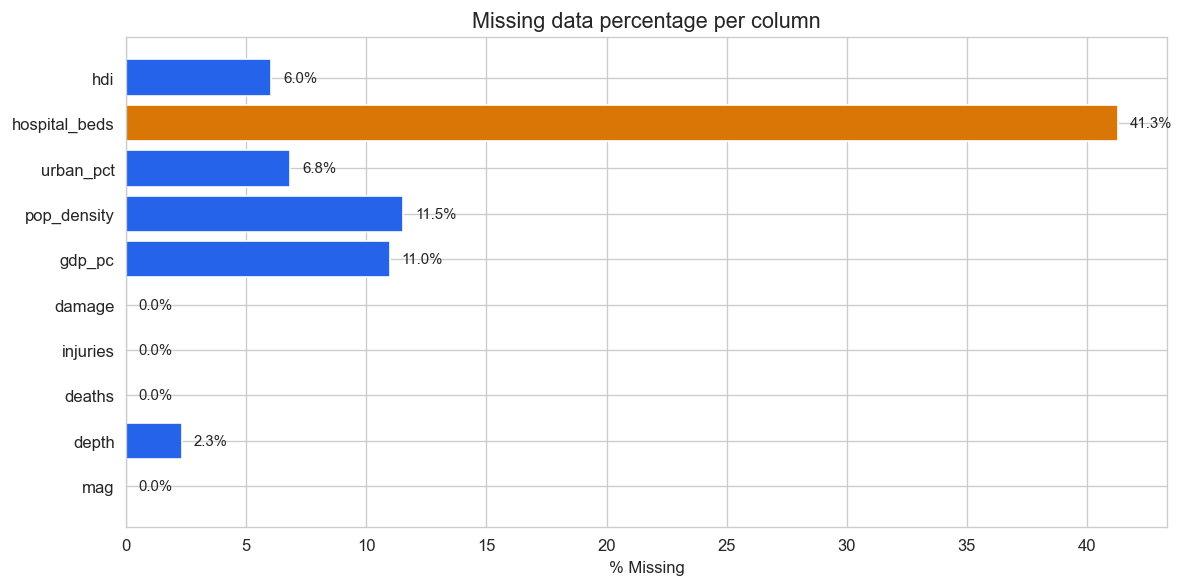

In [48]:
# Overall missing data
missing_cols = ['mag', 'depth', 'deaths', 'injuries', 'damage',
                'gdp_pc', 'pop_density', 'urban_pct', 'hospital_beds', 'hdi']
missing_pct = eq[missing_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2563eb' if p < 20 else '#d97706' if p < 50 else '#dc2626' for p in missing_pct]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colors)
ax.set_xlabel('% Missing')
ax.set_title('Missing data percentage per column')
for bar, pct in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

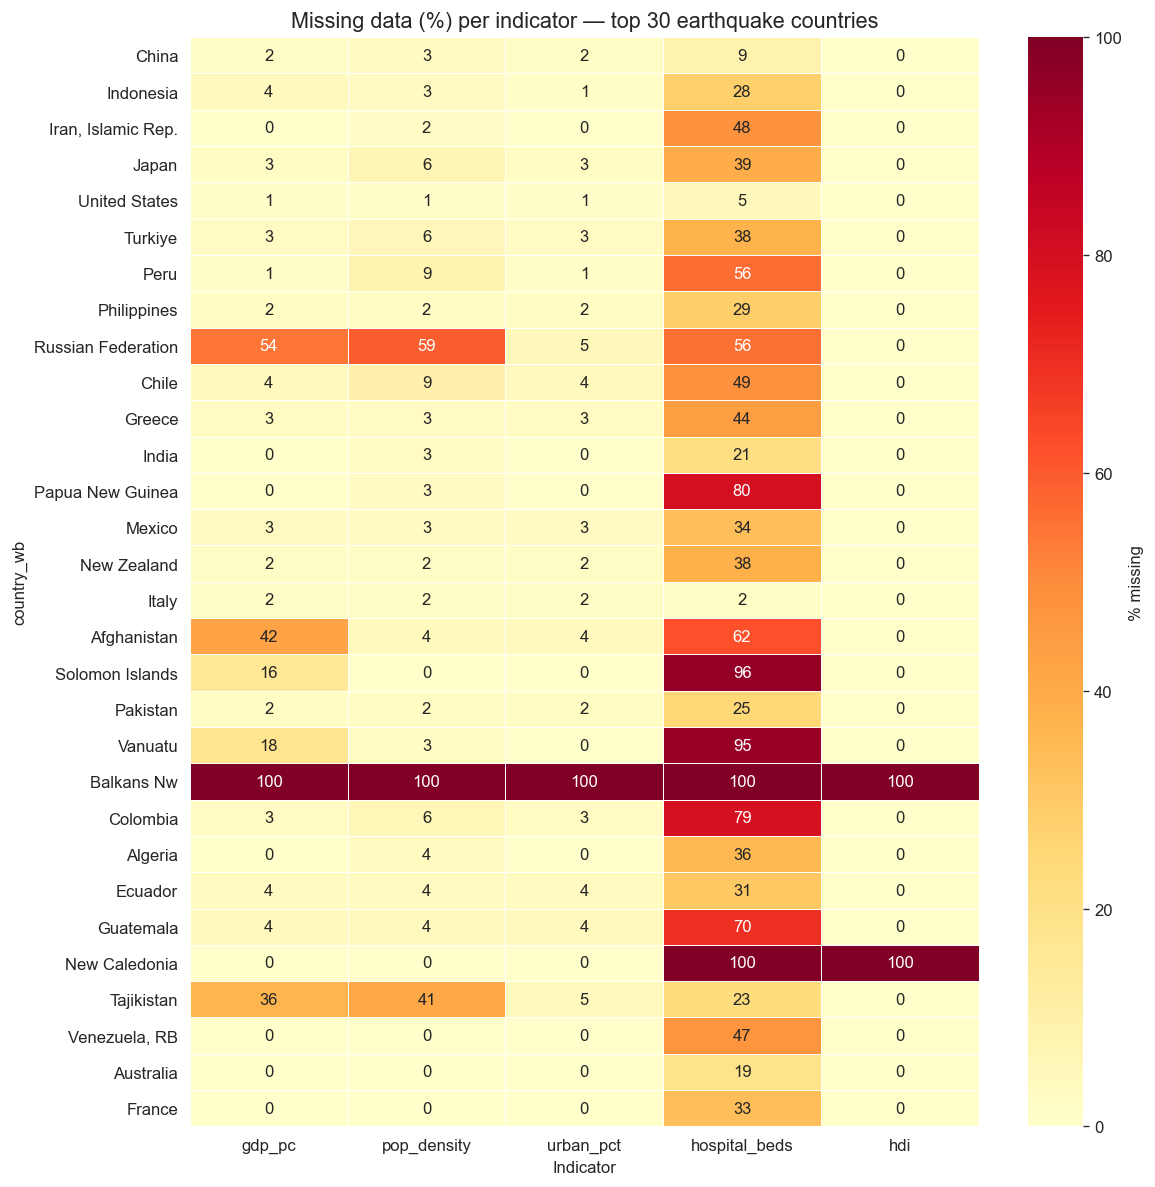

In [49]:
# Missing data heatmap per top 30 countries
indicators = ['gdp_pc', 'pop_density', 'urban_pct', 'hospital_beds', 'hdi']
top30_countries = eq['country_wb'].value_counts().head(30).index.tolist()
eq_top30 = eq[eq['country_wb'].isin(top30_countries)]

missing_by_country = eq_top30.groupby('country_wb')[indicators].apply(
    lambda x: x.isna().mean() * 100
)
missing_by_country = missing_by_country.loc[top30_countries]

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(missing_by_country, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '% missing'}, linewidths=0.5)
ax.set_title('Missing data (%) per indicator — top 30 earthquake countries')
ax.set_xlabel('Indicator')
plt.tight_layout()
plt.show()

---

## 5. Distributions & Visual Insights

### 5.1 Magnitude distribution

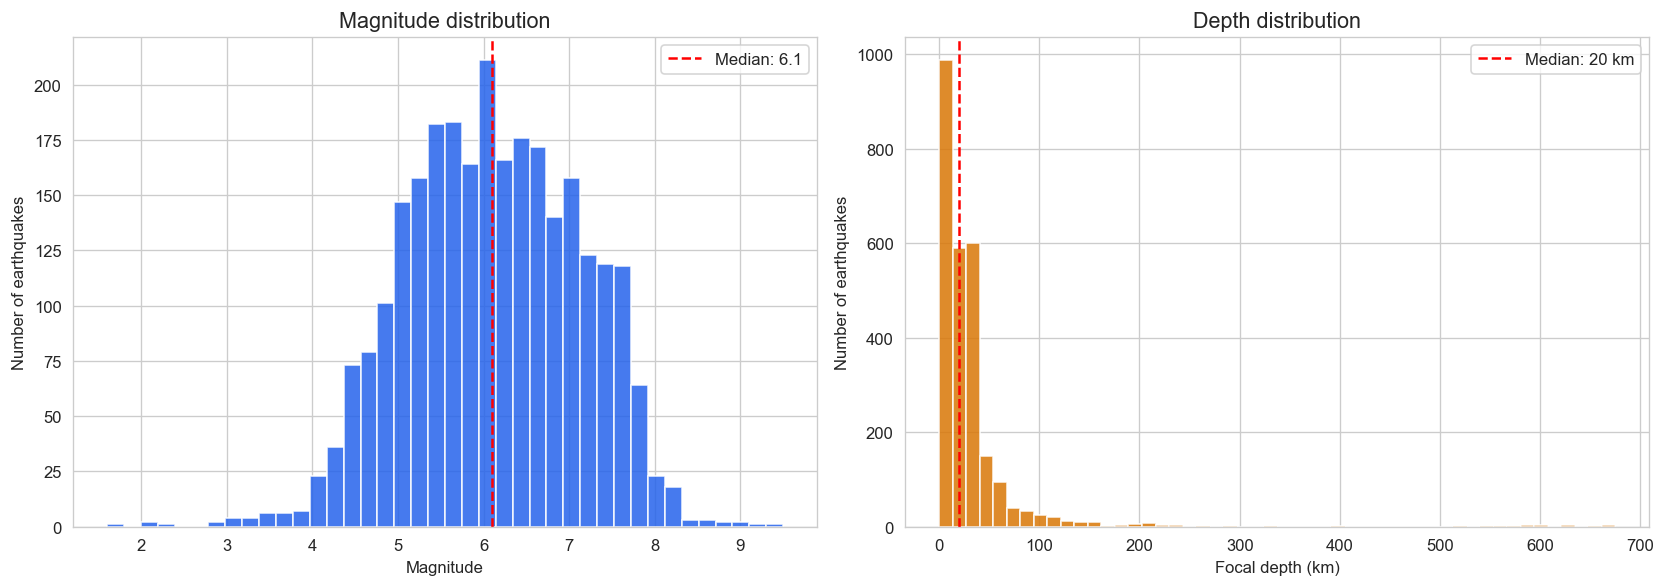

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Magnitude histogram
axes[0].hist(eq['mag'].dropna(), bins=40, color='#2563eb', edgecolor='white', alpha=0.85)
axes[0].axvline(eq['mag'].median(), color='red', linestyle='--', label=f'Median: {eq["mag"].median():.1f}')
axes[0].set_xlabel('Magnitude')
axes[0].set_ylabel('Number of earthquakes')
axes[0].set_title('Magnitude distribution')
axes[0].legend()

# Depth histogram
axes[1].hist(eq['depth'].dropna(), bins=50, color='#d97706', edgecolor='white', alpha=0.85)
axes[1].axvline(eq['depth'].median(), color='red', linestyle='--', label=f'Median: {eq["depth"].median():.0f} km')
axes[1].set_xlabel('Focal depth (km)')
axes[1].set_ylabel('Number of earthquakes')
axes[1].set_title('Depth distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 Deaths distribution (highly skewed)

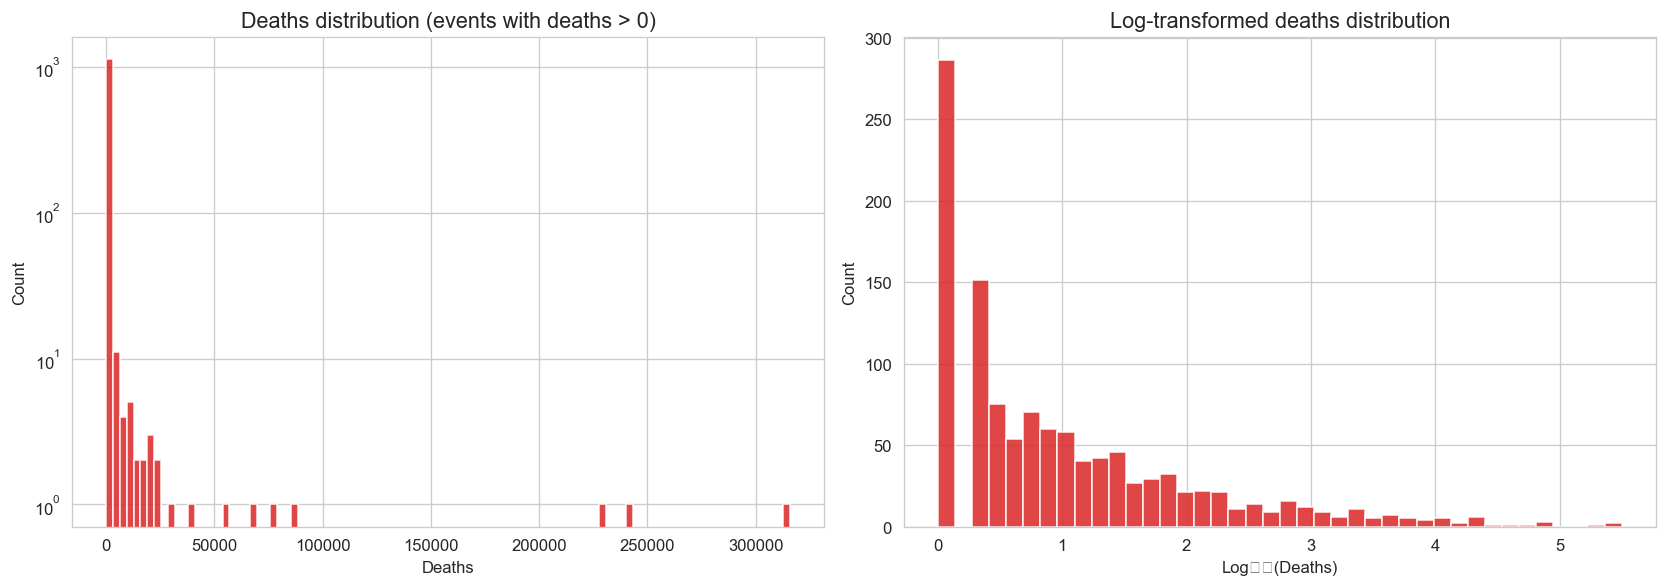

Skewness of deaths:      26.30
Kurtosis of deaths:      760.07
Events with deaths > 0:  1165 (43.5%)


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw deaths (clipped for visibility)
deaths_nonzero = eq[eq['deaths'] > 0]['deaths']
axes[0].hist(deaths_nonzero, bins=100, color='#dc2626', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Deaths')
axes[0].set_ylabel('Count')
axes[0].set_title('Deaths distribution (events with deaths > 0)')
axes[0].set_yscale('log')

# Log-transformed deaths
axes[1].hist(np.log10(deaths_nonzero), bins=40, color='#dc2626', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Log₁₀(Deaths)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-transformed deaths distribution')

plt.tight_layout()
plt.show()

print(f'Skewness of deaths:      {eq["deaths"].skew():.2f}')
print(f'Kurtosis of deaths:      {eq["deaths"].kurtosis():.2f}')
print(f'Events with deaths > 0:  {len(deaths_nonzero)} ({len(deaths_nonzero)/len(eq)*100:.1f}%)')

### 5.3 Events and deaths over time

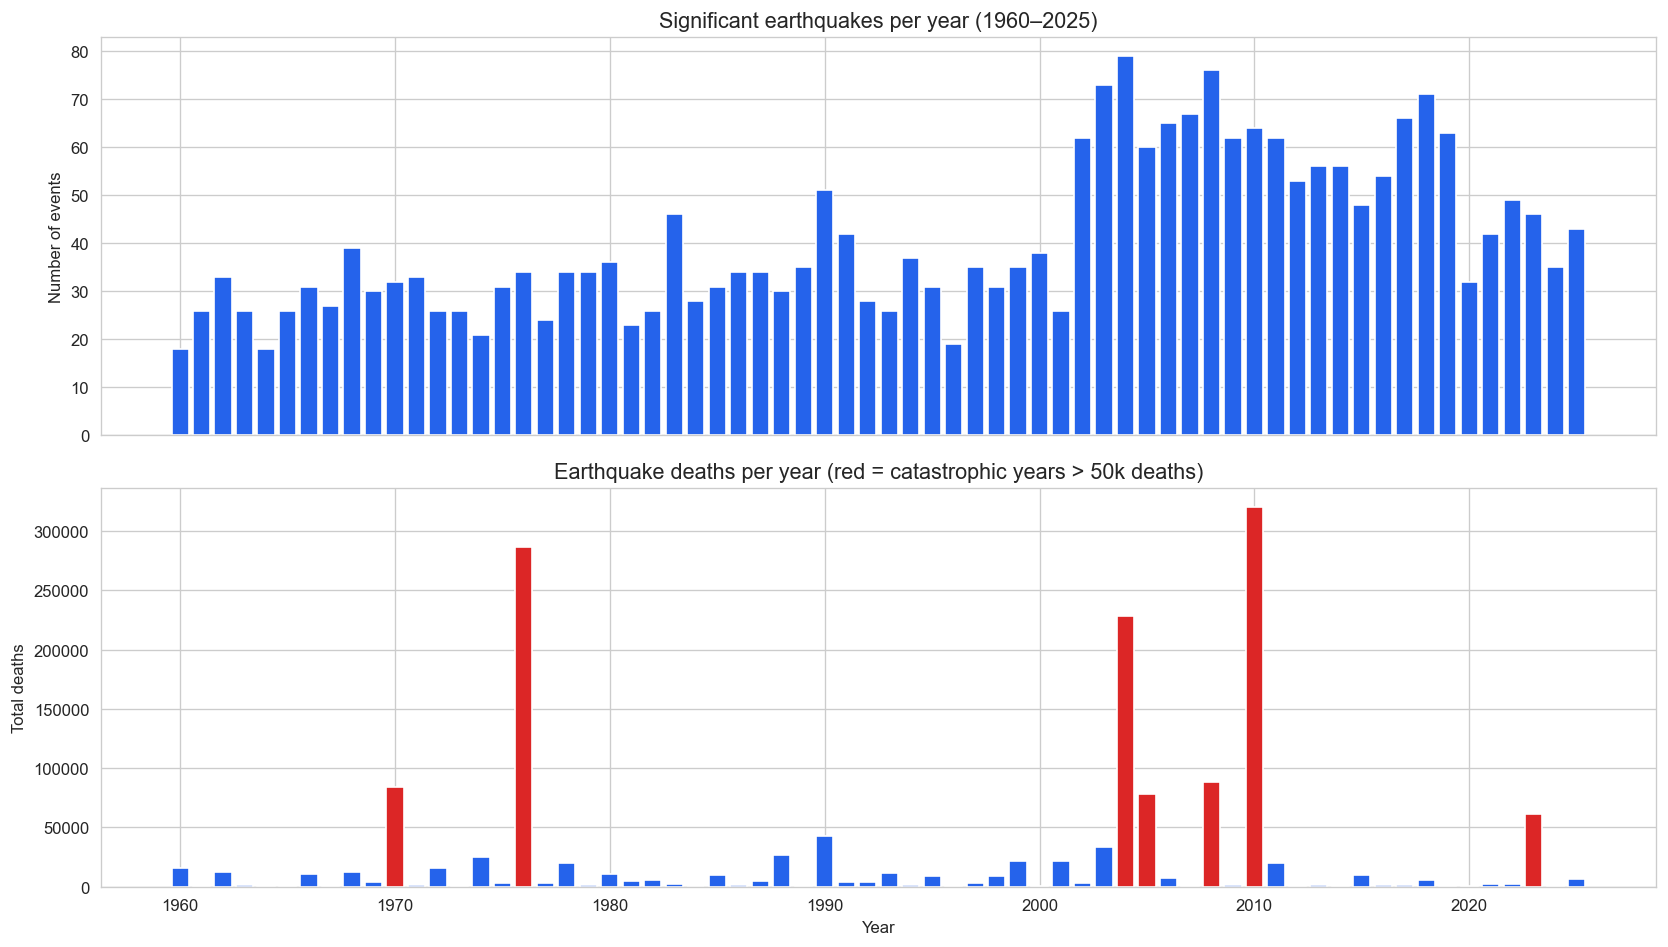

In [52]:
yearly = eq.groupby('year_int').agg(
    events=('deaths', 'count'),
    total_deaths=('deaths', 'sum'),
    avg_mag=('mag', 'mean')
).reset_index()
yearly = yearly[(yearly['year_int'] >= 1960) & (yearly['year_int'] <= 2025)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Events per year
axes[0].bar(yearly['year_int'].astype(int), yearly['events'], color='#2563eb', width=0.8)
axes[0].set_ylabel('Number of events')
axes[0].set_title('Significant earthquakes per year (1960–2025)')

# Deaths per year
bar_colors = ['#dc2626' if d > 50000 else '#2563eb' for d in yearly['total_deaths']]
axes[1].bar(yearly['year_int'].astype(int), yearly['total_deaths'], color=bar_colors, width=0.8)
axes[1].set_ylabel('Total deaths')
axes[1].set_xlabel('Year')
axes[1].set_title('Earthquake deaths per year (red = catastrophic years > 50k deaths)')

plt.tight_layout()
plt.show()

### 5.4 Top 20 countries: deaths vs events

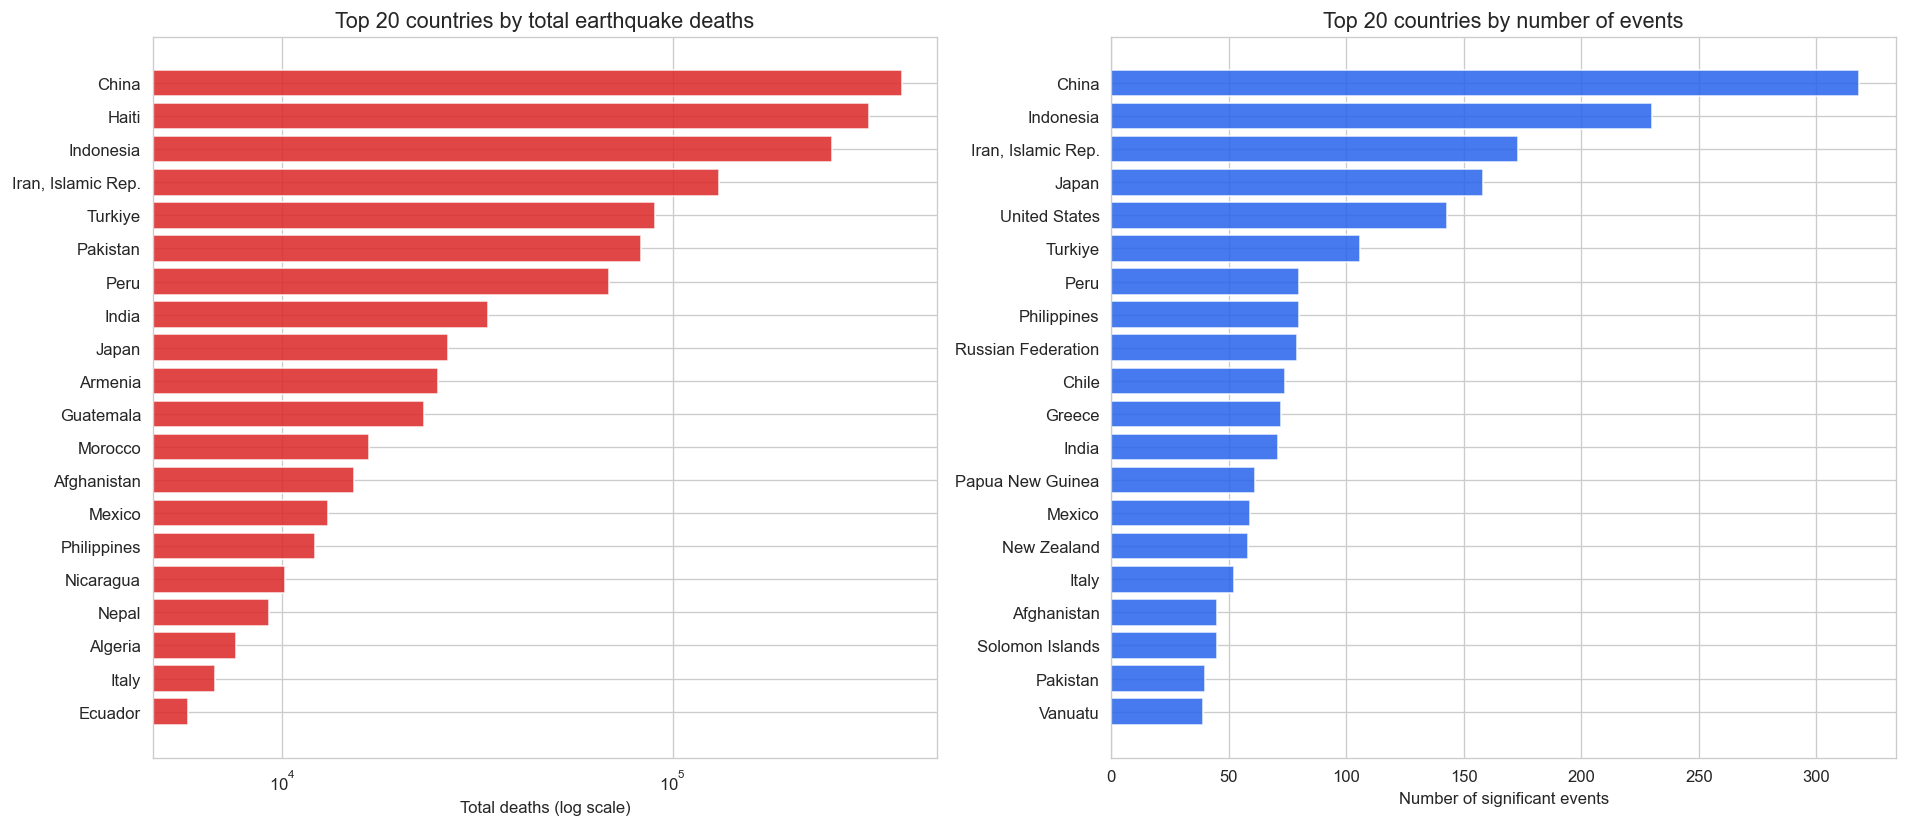

Insight: We can see that even though Japan and the US have high number of events, they do not have as high death toll. 
Here an important confounder is the magnitude of an event and presents the limitation of the visualization.


In [61]:
country_stats = eq.groupby('country_wb').agg(
    events=('deaths', 'count'),
    total_deaths=('deaths', 'sum'),
    avg_mag=('mag', 'mean'),
    avg_gdp=('gdp_pc', 'mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 20 by deaths
top_d = country_stats.nlargest(20, 'total_deaths').sort_values('total_deaths')
axes[0].barh(top_d['country_wb'], top_d['total_deaths'], color='#dc2626', alpha=0.85)
axes[0].set_xscale('log')
axes[0].set_xlabel('Total deaths (log scale)')
axes[0].set_title('Top 20 countries by total earthquake deaths')

# Top 20 by events
top_e = country_stats.nlargest(20, 'events').sort_values('events')
axes[1].barh(top_e['country_wb'], top_e['events'], color='#2563eb', alpha=0.85)
axes[1].set_xlabel('Number of significant events')
axes[1].set_title('Top 20 countries by number of events')

plt.tight_layout()
plt.show()

print('Insight: We can see that even though Japan and the US have high number of events, they do not have as high death toll. ')
print('Here an important confounder is the magnitude of an event and presents the limitation of the visualization.')

### 5.5 Magnitude vs Deaths scatter

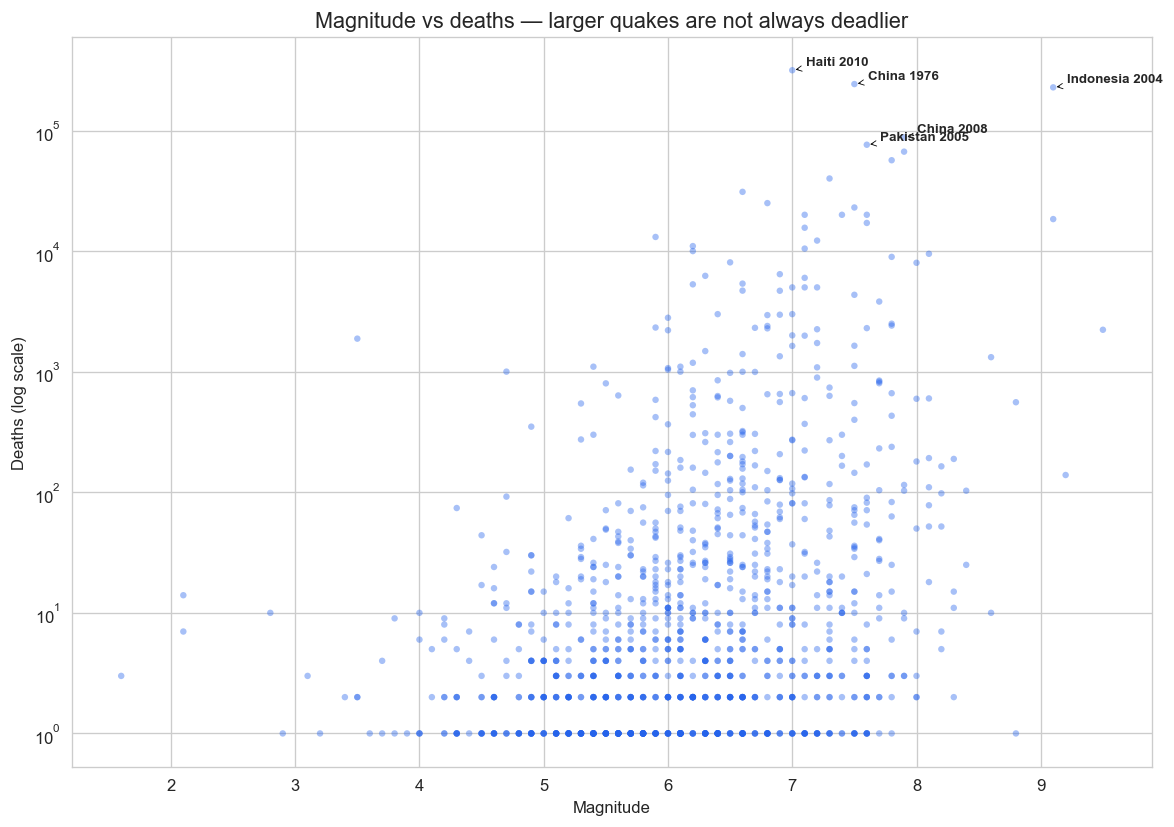

Pearson r (mag vs log-deaths): 0.361 (p=3.37e-37)
Insight: Magnitude alone is not enough to predict deaths. Context (wealth, infrastructure) matters.


In [57]:
deadly = eq[eq['deaths'] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(deadly['mag'], deadly['deaths'], alpha=0.4, s=15, c='#2563eb', edgecolors='none')
ax.set_yscale('log')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Deaths (log scale)')
ax.set_title('Magnitude vs deaths — larger quakes are not always deadlier')

# Annotate notable events
notable = deadly.nlargest(5, 'deaths')
for _, row in notable.iterrows():
    label = f"{row['country_wb']} {int(row['year'])}" if pd.notna(row['country_wb']) else str(int(row['year']))
    ax.annotate(label, (row['mag'], row['deaths']),
                fontsize=8, fontweight='bold', xytext=(8, 3),
                textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black', lw=0.5))

plt.tight_layout()
plt.show()

r, p = stats.pearsonr(deadly['mag'], np.log10(deadly['deaths']))
print(f'Pearson r (mag vs log-deaths): {r:.3f} (p={p:.2e})')
print('Insight: Magnitude alone is not enough to predict deaths. Context (wealth, infrastructure) matters.')

### 5.6 Correlation matrix

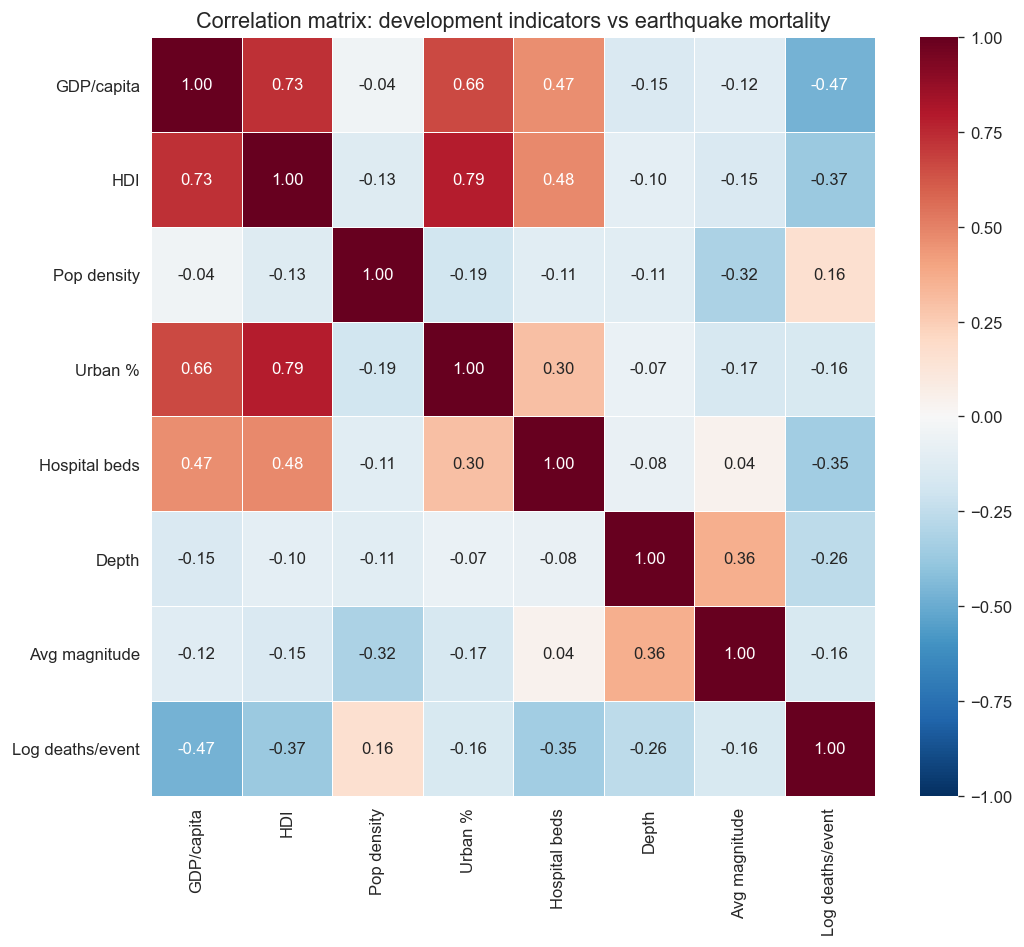

Key correlations with Log deaths/event:
  GDP/capita          : r = -0.469 
  HDI                 : r = -0.374 
  Hospital beds       : r = -0.349 
  Depth               : r = -0.260 
  Urban %             : r = -0.161 
  Avg magnitude       : r = -0.157 
  Pop density         : r = +0.158 


In [58]:
# Aggregate per country for correlation analysis
country_agg = eq.groupby('country_wb').agg(
    events=('deaths', 'count'),
    total_deaths=('deaths', 'sum'),
    avg_mag=('mag', 'mean'),
    avg_gdp=('gdp_pc', 'mean'),
    avg_pop_density=('pop_density', 'mean'),
    avg_urban_pct=('urban_pct', 'mean'),
    avg_hospital_beds=('hospital_beds', 'mean'),
    avg_depth=('depth', 'mean'),
    hdi=('hdi', 'first'),
).reset_index()
country_agg = country_agg[country_agg['events'] >= 5].copy()
country_agg['deaths_per_event'] = country_agg['total_deaths'] / country_agg['events']

corr_cols = ['avg_gdp', 'hdi', 'avg_pop_density', 'avg_urban_pct',
             'avg_hospital_beds', 'avg_depth', 'avg_mag', 'deaths_per_event']
corr_data = country_agg[corr_cols].copy()
corr_data['deaths_per_event'] = np.log10(corr_data['deaths_per_event'].clip(lower=0.01))
corr_data.columns = ['GDP/capita', 'HDI', 'Pop density', 'Urban %',
                      'Hospital beds', 'Depth', 'Avg magnitude', 'Log deaths/event']

corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation matrix: development indicators vs earthquake mortality')
plt.tight_layout()
plt.show()

print('Key correlations with Log deaths/event:')
corr_with_deaths = corr_matrix['Log deaths/event'].drop('Log deaths/event').sort_values()
for name, val in corr_with_deaths.items():
    print(f'  {name:20s}: r = {val:+.3f} ')

### 5.7 GDP vs Deaths per event

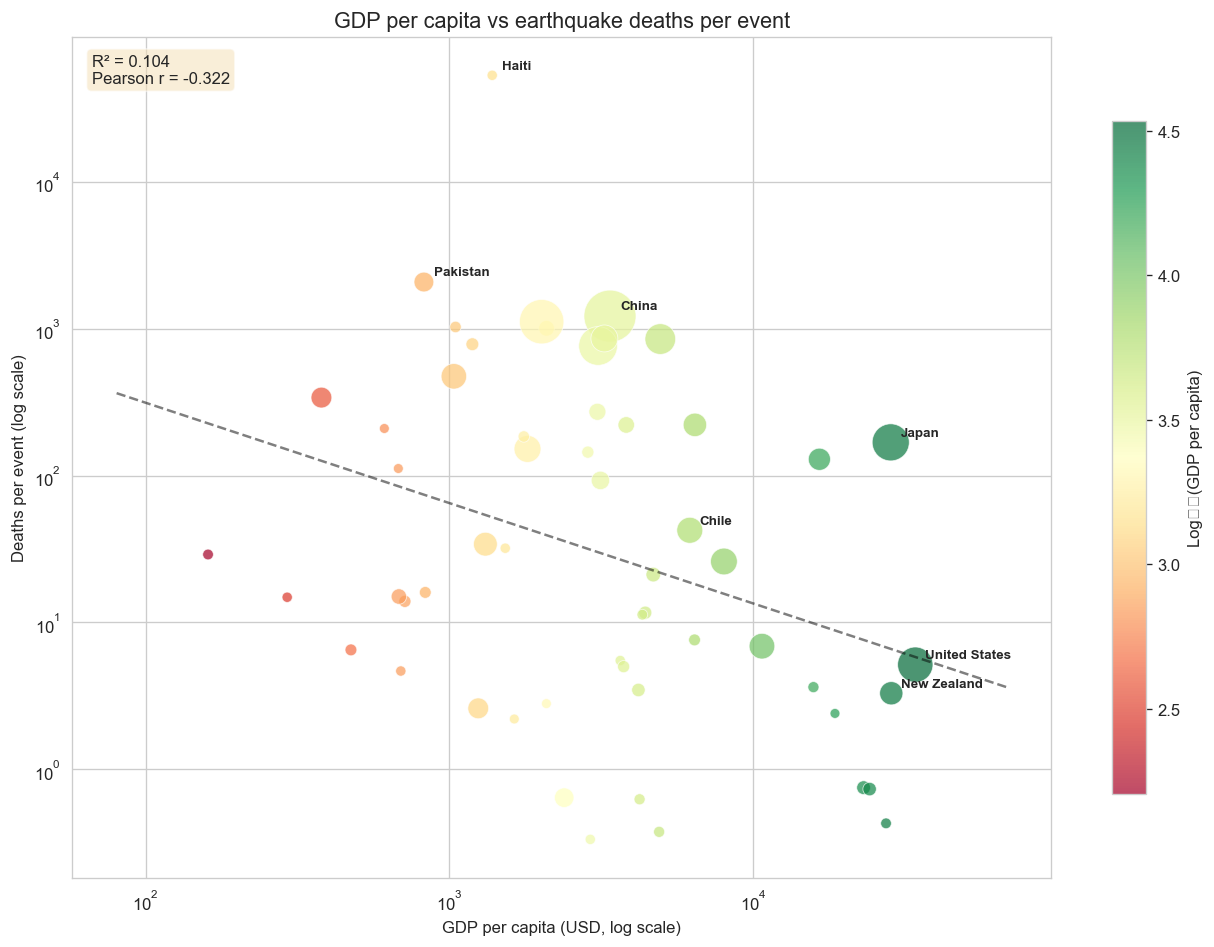

R² = 0.104, p-value = 1.55e-02
Insight: Wealthier countries consistently suffer fewer deaths per earthquake event.


In [56]:
df_plot = country_agg.dropna(subset=['avg_gdp', 'deaths_per_event']).copy()
df_plot = df_plot[df_plot['deaths_per_event'] > 0].copy()

fig, ax = plt.subplots(figsize=(11, 8))
scatter = ax.scatter(
    df_plot['avg_gdp'], df_plot['deaths_per_event'],
    s=df_plot['events'] * 3 + 20, alpha=0.7,
    c=np.log10(df_plot['avg_gdp']), cmap='RdYlGn', edgecolors='white', linewidth=0.5
)

# Regression line (log-log)
slope, intercept, r_value, p_value, _ = stats.linregress(
    np.log10(df_plot['avg_gdp']), np.log10(df_plot['deaths_per_event'])
)
x_line = np.logspace(np.log10(df_plot['avg_gdp'].min() * 0.5),
                     np.log10(df_plot['avg_gdp'].max() * 2), 100)
y_line = 10 ** (intercept + slope * np.log10(x_line))
ax.plot(x_line, y_line, 'k--', alpha=0.5, linewidth=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('GDP per capita (USD, log scale)')
ax.set_ylabel('Deaths per event (log scale)')
ax.set_title('GDP per capita vs earthquake deaths per event')

ax.text(0.02, 0.98, f'R² = {r_value**2:.3f}\nPearson r = {r_value:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Annotate key countries
for c in ['Haiti', 'Japan', 'Pakistan', 'Chile', 'New Zealand', 'China', 'United States']:
    row = df_plot[df_plot['country_wb'] == c]
    if len(row):
        label = c.replace(', Islamic Rep.', '').replace(', RB', '')
        ax.annotate(label, (row['avg_gdp'].values[0], row['deaths_per_event'].values[0]),
                    fontsize=8, fontweight='bold', xytext=(6, 4), textcoords='offset points')

plt.colorbar(scatter, label='Log₁₀(GDP per capita)', shrink=0.8)
plt.tight_layout()
plt.show()

print(f'R² = {r_value**2:.3f}, p-value = {p_value:.2e}')
print('Insight: Wealthier countries consistently suffer fewer deaths per earthquake event.')